In [255]:
import string 
import re
import codecs
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import feature_extraction
from sklearn import linear_model
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import pipeline
from sklearn.model_selection import train_test_split
from sklearn import metrics
import itertools

In [256]:
dataset = pd.read_csv('language-detection/Language Detection.csv')

In [257]:
dataset.head()

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


In [258]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10337 entries, 0 to 10336
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      10337 non-null  object
 1   Language  10337 non-null  object
dtypes: object(2)
memory usage: 161.6+ KB


In [259]:
dataset["Language"].value_counts()

Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64

In [260]:
X = dataset["Text"]
y = dataset["Language"]

<Axes: xlabel='Language', ylabel='count'>

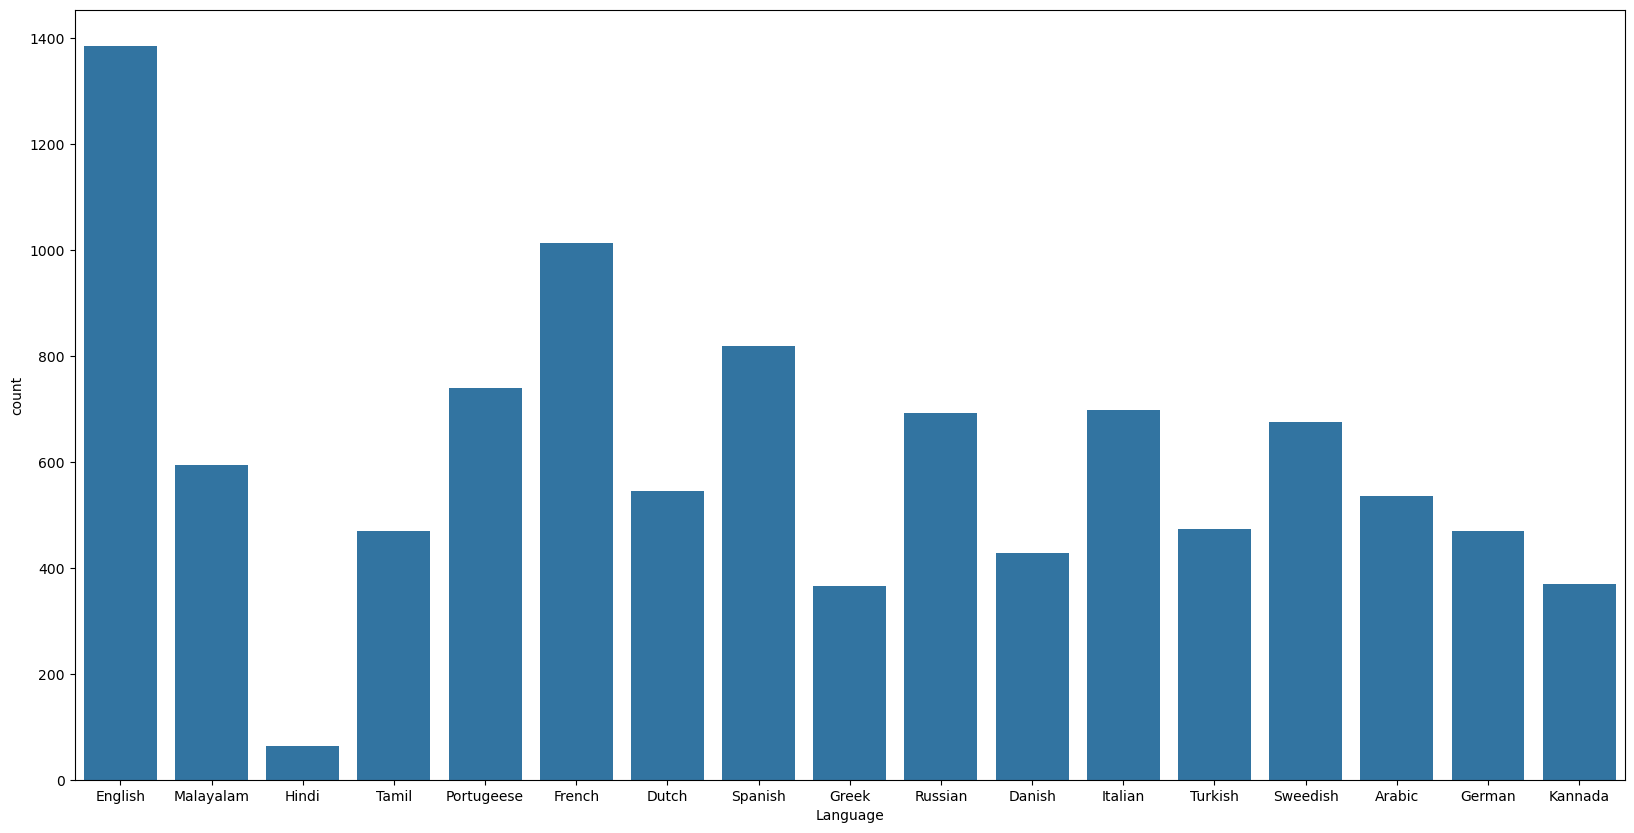

In [261]:
plt.figure(figsize=(20,10))
sns.countplot(x = dataset['Language'], data=dataset)

In [262]:
X.head()

0     Nature, in the broadest sense, is the natural...
1    "Nature" can refer to the phenomena of the phy...
2    The study of nature is a large, if not the onl...
3    Although humans are part of nature, human acti...
4    [1] The word nature is borrowed from the Old F...
Name: Text, dtype: object

In [263]:
y.head()
y.tail()

10332    Kannada
10333    Kannada
10334    Kannada
10335    Kannada
10336    Kannada
Name: Language, dtype: object

In [264]:
# creating a list for appending the preprocessed text
data_list = []
# iterating through all the text
for text in X:
       # removing the symbols and numbers
        text = re.sub(r'[!@#$(),n"%^*?:;~`0-9]', ' ', text)
        text = re.sub(r'\[|\]', ' ', text)
        # converting the text to lower case
        text = text.lower()
        # appending to data_list
        data_list.append(text)

In [265]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [266]:
vectorizer = feature_extraction.text.TfidfVectorizer(ngram_range=(1,3), analyzer='char')
# x = vectorizer.fit_transform(df['Text'])

In [267]:
pipe_mnb = pipeline.Pipeline([
    ('vectorizer', vectorizer),
    ('clf', MultinomialNB())
])

In [268]:
pipe_mnb.fit(x_train, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char', ngram_range=(1, 3))),
                ('clf', MultinomialNB())])

In [269]:
pipe_lr = pipeline.Pipeline([
    ('vectorizer', vectorizer),
    ('lr_clf', LogisticRegression())
])

In [270]:
pipe_lr.fit(x_train, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char', ngram_range=(1, 3))),
                ('lr_clf', LogisticRegression())])

In [271]:
pipe_rf = pipeline.Pipeline([
    ('vectorizer', vectorizer),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [272]:
pipe_rf.fit(x_train, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char', ngram_range=(1, 3))),
                ('clf', RandomForestClassifier(random_state=42))])

In [273]:
pipe_dt = pipeline.Pipeline([
    ('vectorizer', vectorizer),
    ('clf', DecisionTreeClassifier(random_state=42))
])

In [274]:
pipe_dt.fit(x_train, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char', ngram_range=(1, 3))),
                ('clf', DecisionTreeClassifier(random_state=42))])

In [275]:
lr_predicted = pipe_lr.predict(x_test)
lr_acc = (metrics.accuracy_score(y_test, lr_predicted))*100
print('The logistic regression has:',lr_acc,'% accuracy')

The logistic regression has: 98.35589941972921 % accuracy


In [276]:
mnb_predicted = pipe_mnb.predict(x_test)
mnb_acc = (metrics.accuracy_score(y_test, mnb_predicted))*100
print('The MultinomialNB has :',mnb_acc,'% accuracy')

The MultinomialNB has : 84.62282398452611 % accuracy


In [277]:
rf_predicted = pipe_rf.predict(x_test)
rf_acc = (metrics.accuracy_score(y_test, mnb_predicted))*100
print('The Randomforest has :',rf_acc,'% accuracy')

The Randomforest has : 84.62282398452611 % accuracy


In [278]:
dt_predicted = pipe_dt.predict(x_test)
dt_acc = (metrics.accuracy_score(y_test, dt_predicted))*100
print('The Decisiontree has :',dt_acc,'% accuracy')

The Decisiontree has : 88.68471953578336 % accuracy


In [279]:
matrix = metrics.confusion_matrix(y_test, lr_predicted)
print('Confusion matrix: \n', matrix)

Confusion matrix: 
 [[106   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0  70   0   0   0   0   0   0   0   0   0   0   0   0   3   0   0]
 [  0   0 107   3   0   1   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 290   0   0   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0   2 215   0   0   0   1   0   0   1   0   0   0   0   0]
 [  0   0   2   1   0  89   0   0   0   0   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0  68   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  10   0   0   0   0   0   0   0   0   0]
 [  0   1   0   1   0   0   0   0 141   0   0   0   0   1   0   0   1]
 [  0   0   0   0   0   0   0   0   0  66   0   0   0   0   0   0   0]
 [  0   0   0   1   0   0   0   0   0   0 120   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   0   0 141   0   1   0   0   1]
 [  0   0   0   0   0   0   0   0   0   0   0   0 136   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   0   0   2   1 156

In [280]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Actual labels',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization


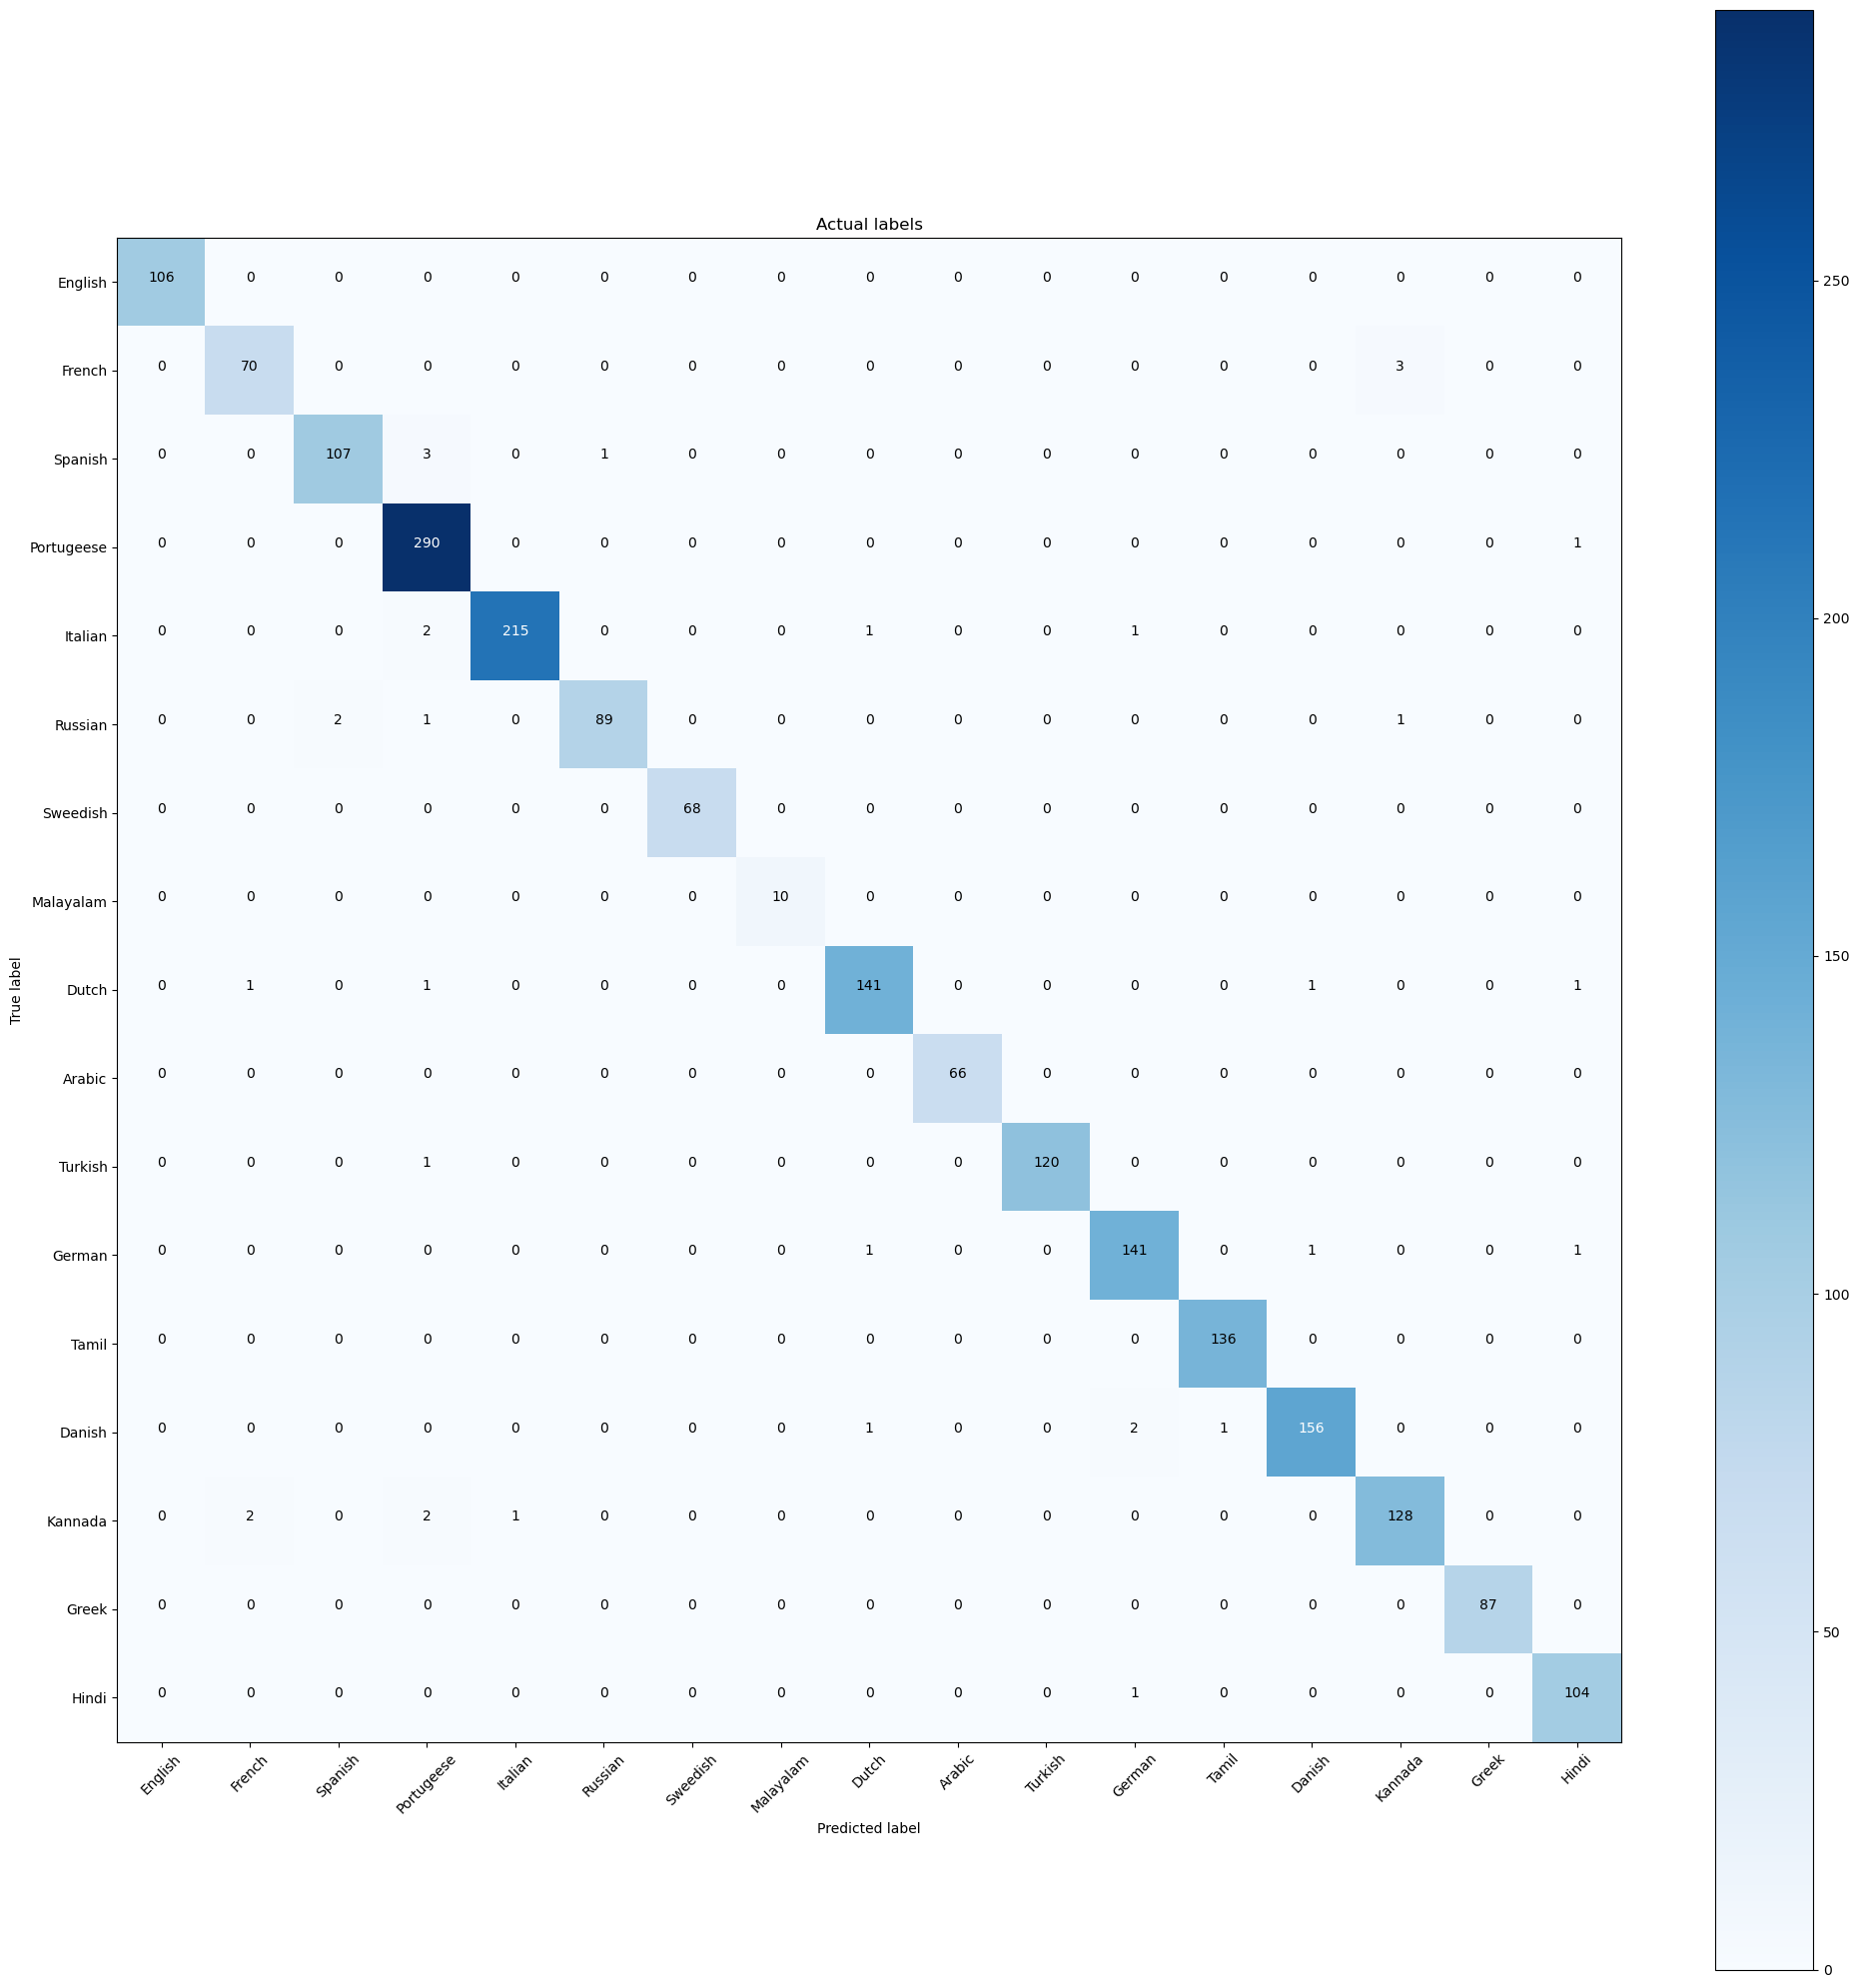

In [281]:
plt.figure(figsize=(20,20))
plot_confusion_matrix(matrix, classes = ['English','French','Spanish','Portugeese','Italian','Russian','Sweedish','Malayalam','Dutch','Arabic','Turkish','German','Tamil','Danish','Kannada','Greek','Hindi'])


In [282]:
import pickle

In [283]:
lrfile = open('lrmodel.pckl', 'wb')
pickle.dump(pipe_lr, lrfile)
lrfile.close()

In [284]:
with open('lrmodel.pckl', 'rb') as lrfile:
    lor = pickle.load(lrfile)


In [286]:
lor.predict(['hello'])


array(['English'], dtype=object)

In [290]:
lor.predict(['भाषा का पता लगाएं'])

array(['Hindi'], dtype=object)

In [294]:
lor.predict(['അത് പരീക്ഷിച്ചുനോക്കുന്നതിന്, ചുവടെ നിങ്ങളുടെ ഭാഷയും എഴുത്ത് ഉപകരണങ്ങളും തിരഞ്ഞെടുത്ത് .'])

array(['Malayalam'], dtype=object)